In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '20')
mpl.rc('xtick', labelsize=18) 
mpl.rc('ytick', labelsize=18)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
#Definimos las direcciones de los archivos
tlargo = True

if tlargo == False:
    #Tiempos cortos (eta_max = 100, N = 128)
    dir_lphi4 = "./build_lphi4/data/short/"
    dir_tanh4 = "./build_tanh4/data/short/"

else:
    #Tiempos largos (eta_max = 900, N = 64)
    dir_lphi4 = "./build_lphi4/data/var_lambda/lambda_9e-14/"
    dir_tanh4 = "./build_tanh4/data/lambda_9e-14/L4_1.7966e65/"
    #dir_lphi4 = "./build_lphi4/data/long/"
    #dir_tanh4 = "./build_tanh4/data/long/"

# Buscamos las bandas de resonancia

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

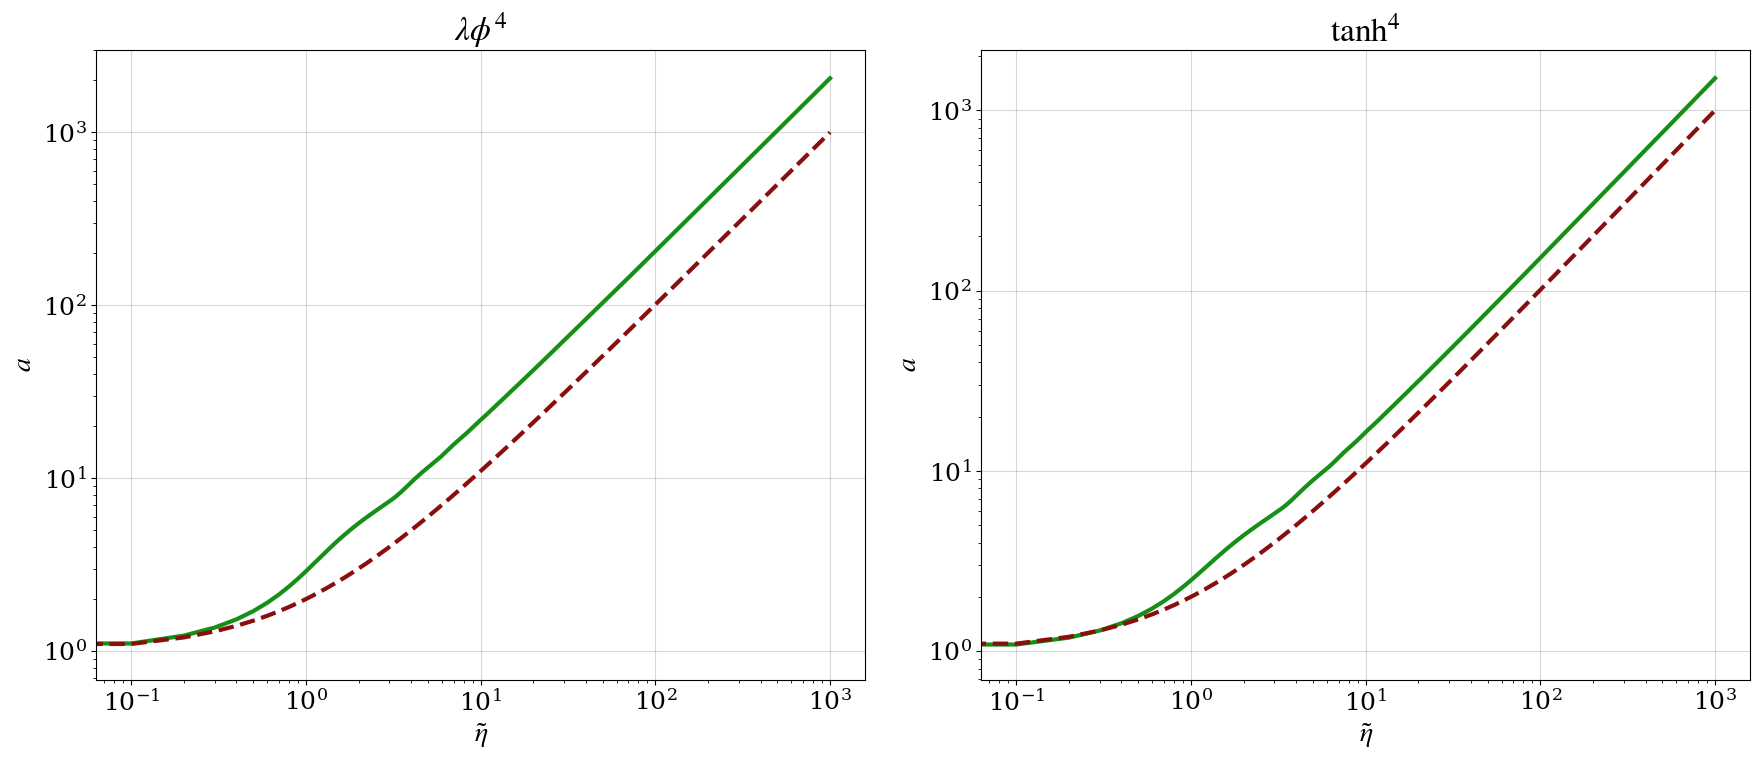

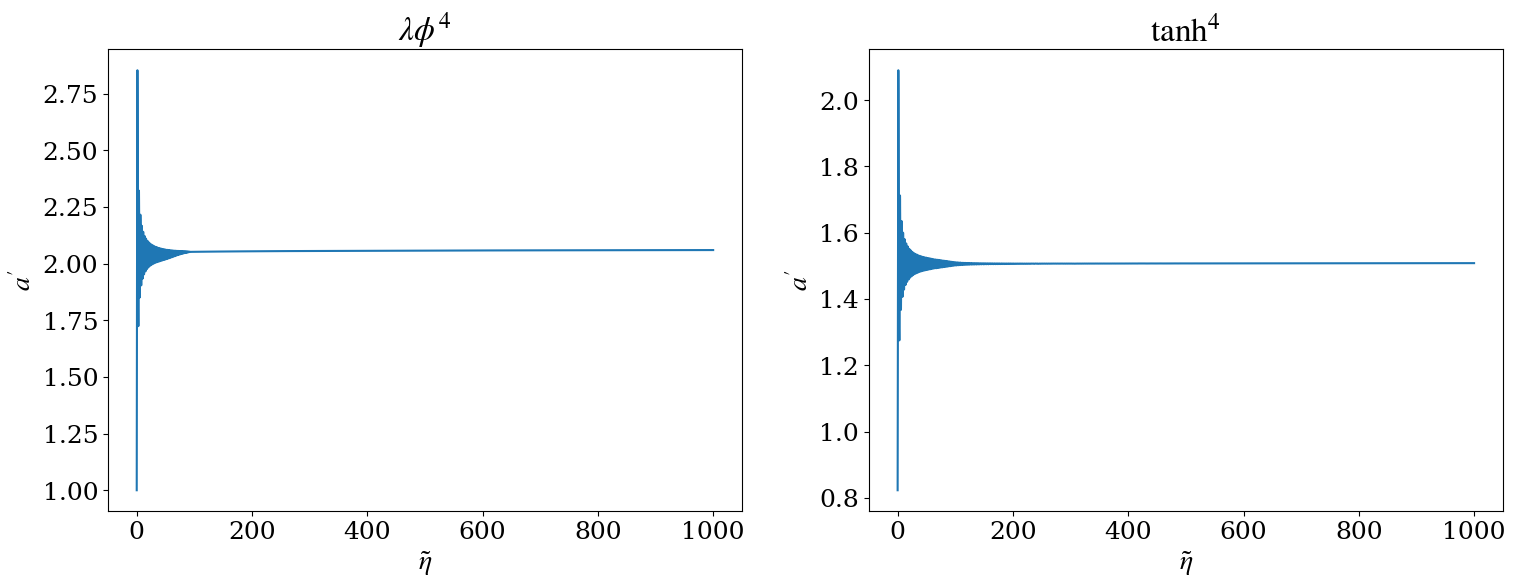

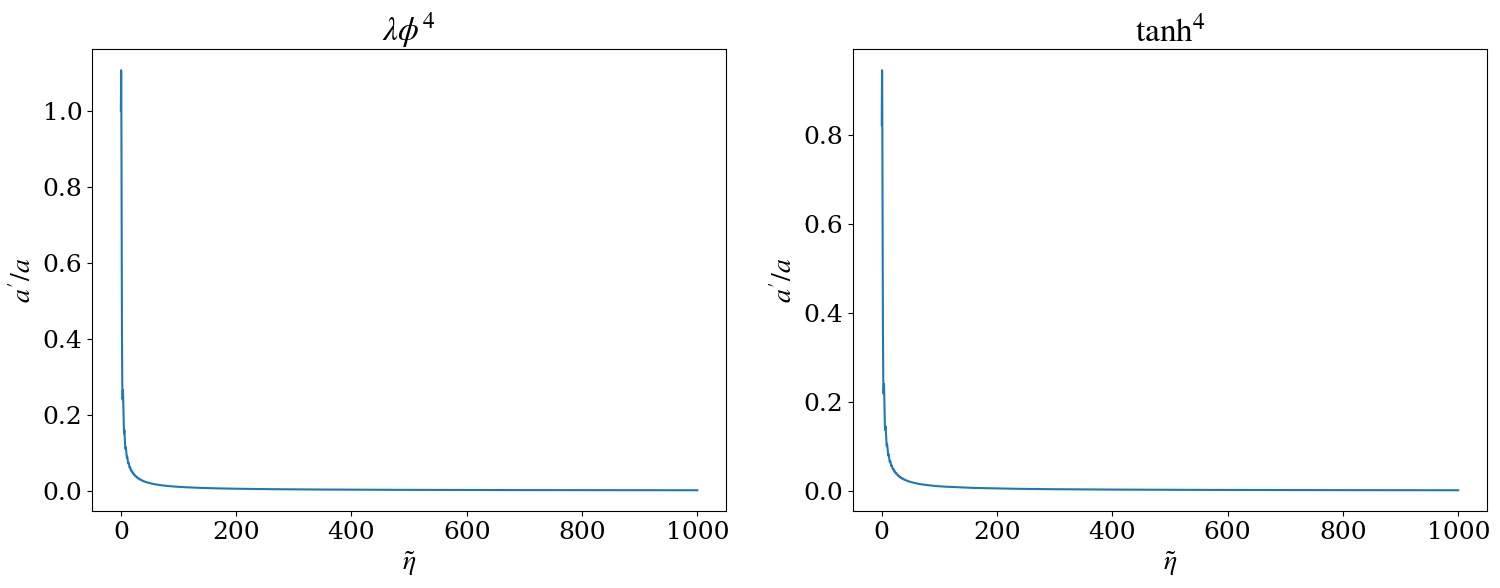

In [3]:
expansion = True

if expansion == True:
    # load the file in aDat
    aDat_lphi4 = np.loadtxt(dir_lphi4 + "average_scale_factor.txt")
    aDat_tanh4 = np.loadtxt(dir_tanh4 + "average_scale_factor.txt")

    #plot a
    plt.figure(figsize=(18, 8))
    
    plt.subplot(1, 2, 1)
    plt.plot(aDat_lphi4[:,0], aDat_lphi4[:,1], color = "#168F16", lw = 3)
    plt.plot(aDat_lphi4[:,0], aDat_lphi4[:,0]+1, ls = "--", color = "#8a0e0e", lw = 3)
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r"$\lambda \phi^4$")
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(alpha = 0.5)

    plt.subplot(1, 2, 2)
    plt.plot(aDat_tanh4[:,0], aDat_tanh4[:,1], color = "#168F16", lw = 3)
    plt.plot(aDat_tanh4[:,0], aDat_tanh4[:,0]+1, ls = "--", color = "#8a0e0e", lw = 3)
    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.title(r"$\tanh^4$")
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(alpha = 0.5)

    plt.tight_layout()
    plt.savefig("CosmoLattice_background_a_lphi4tanh4.pdf", format = "pdf")


    #plot a'
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(aDat_lphi4[:,0], aDat_lphi4[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r"$\lambda \phi^4$")

    plt.subplot(1, 2, 2)
    plt.plot(aDat_tanh4[:,0], aDat_tanh4[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r"$\tanh^4$")

    #plot a'/a
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 2, 1)
    plt.plot(aDat_lphi4[:,0], aDat_lphi4[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r"$\lambda \phi^4$")

    plt.subplot(1, 2, 2)
    plt.plot(aDat_tanh4[:,0], aDat_tanh4[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    plt.title(r"$\tanh^4$")

else:
    aDat_lphi4 = None
    aDat_tanh4 = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [4]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    if aDat is not None:
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

    else:
        plt.plot(fldDat[:,0], fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")

## Field $0$ (inflaton)

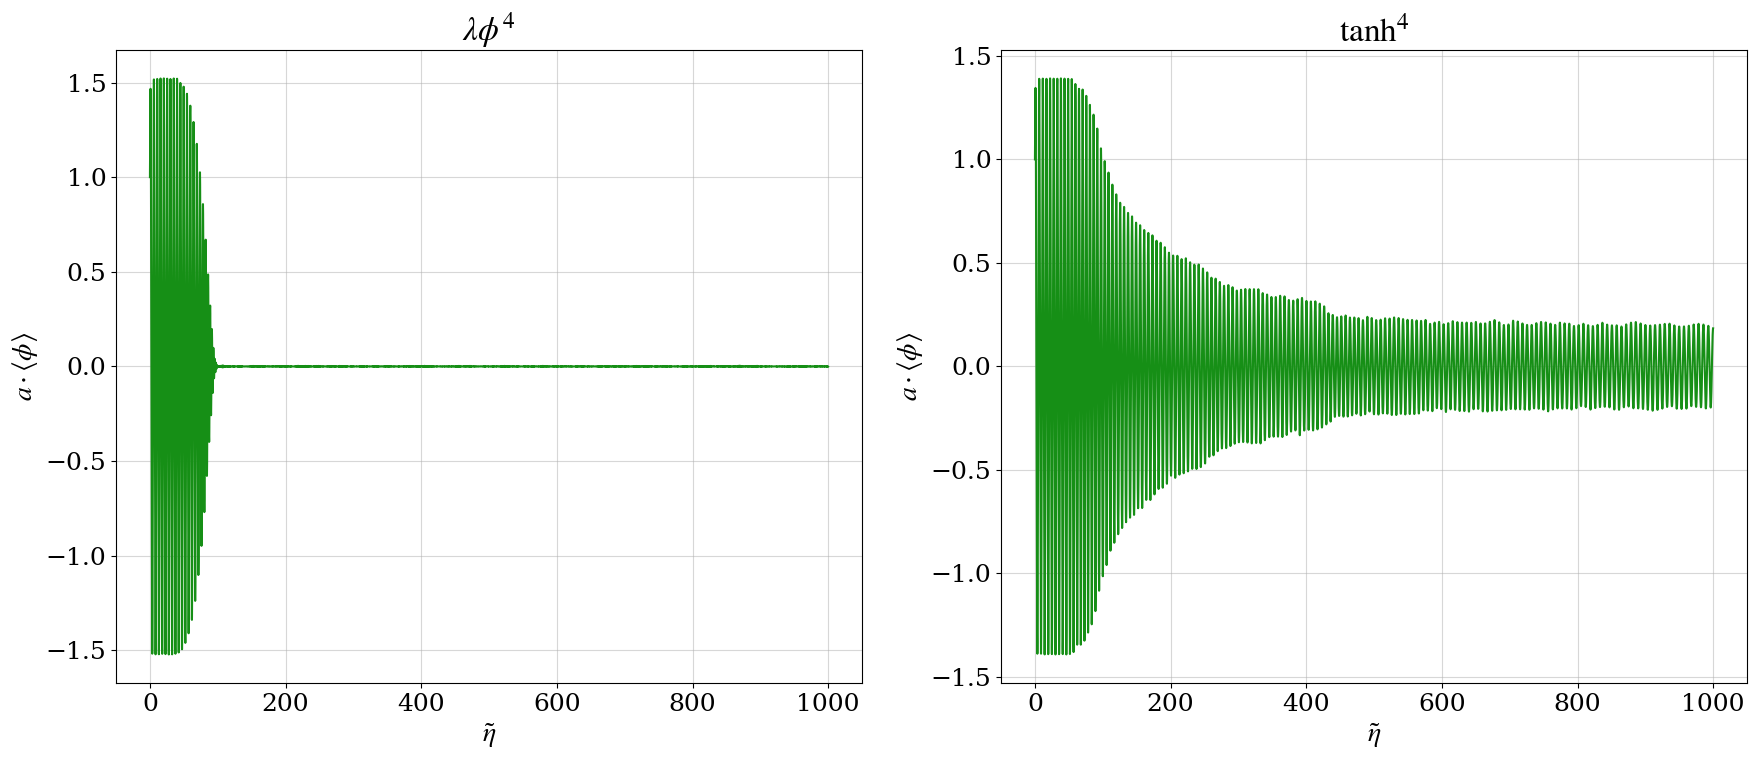

In [5]:
infDat_lphi4 = np.loadtxt(dir_lphi4 + "average_scalar_0.txt")
infDat_tanh4 = np.loadtxt(dir_tanh4 + "average_scalar_0.txt")

plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plt.plot(infDat_lphi4[:,0], aDat_lphi4[:,1] * infDat_lphi4[:,1], color = "#168F16")
plt.xlabel("$\\tilde\eta$")
plt.ylabel(r"$a\cdot\langle \phi \rangle$")
plt.title(r'$\lambda \phi^4$')
plt.grid(alpha = 0.5)

plt.subplot(1, 2, 2)
plt.plot(infDat_tanh4[:,0], aDat_tanh4[:,1] * infDat_tanh4[:,1], color = "#168F16")
plt.xlabel("$\\tilde\eta$")
plt.ylabel(r"$a\cdot\langle \phi \rangle$")
plt.title(r'$\tanh^4$')
plt.grid(alpha = 0.5)


plt.tight_layout()
plt.savefig("CosmoLattice_background_phi_lphi4tanh4.pdf", format = "pdf")

## Field $1$ (daughter field)

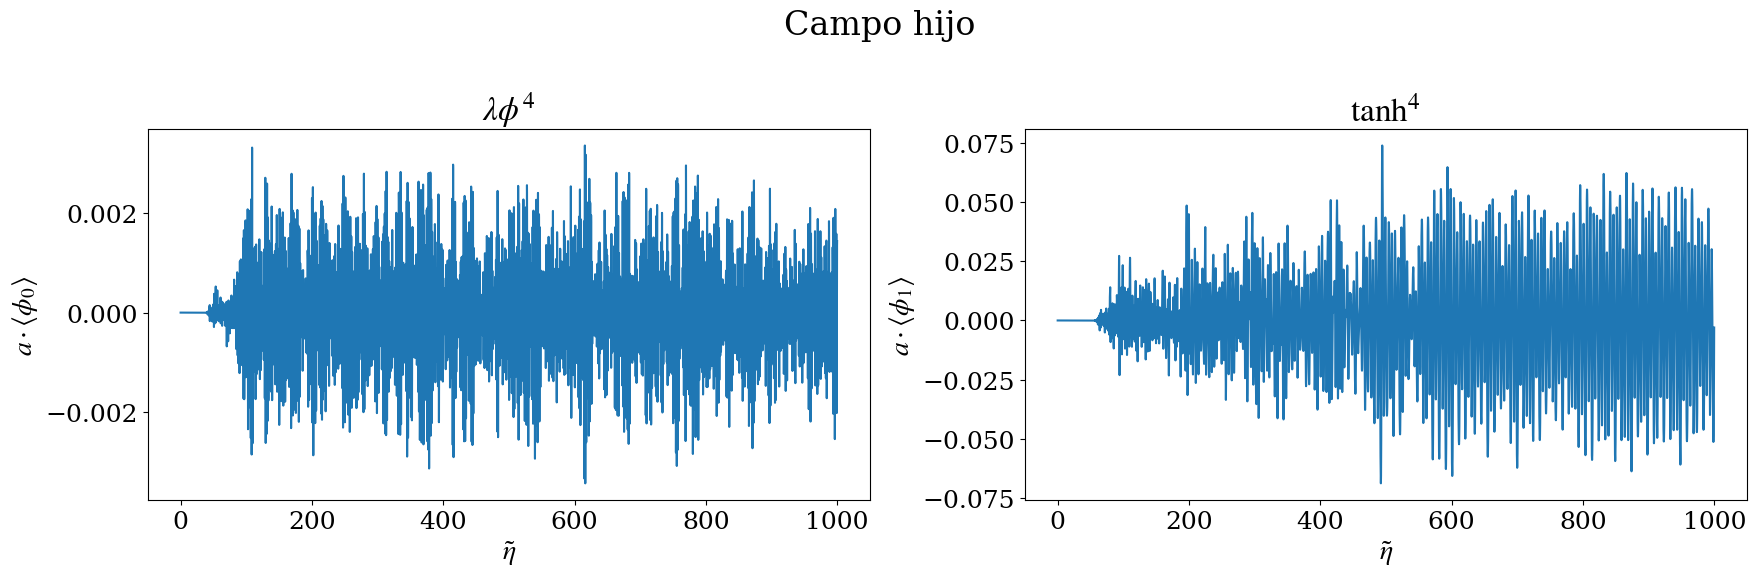

In [6]:
infDat_lphi4 = np.loadtxt(dir_lphi4 + "average_scalar_1.txt")
infDat_tanh4 = np.loadtxt(dir_tanh4 + "average_scalar_1.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_fld(infDat_lphi4,"0",aDat_lphi4)
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plot_fld(infDat_tanh4,"1",aDat_tanh4)
plt.title(r'$\tanh^4$')

plt.suptitle(r'Campo hijo')
plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

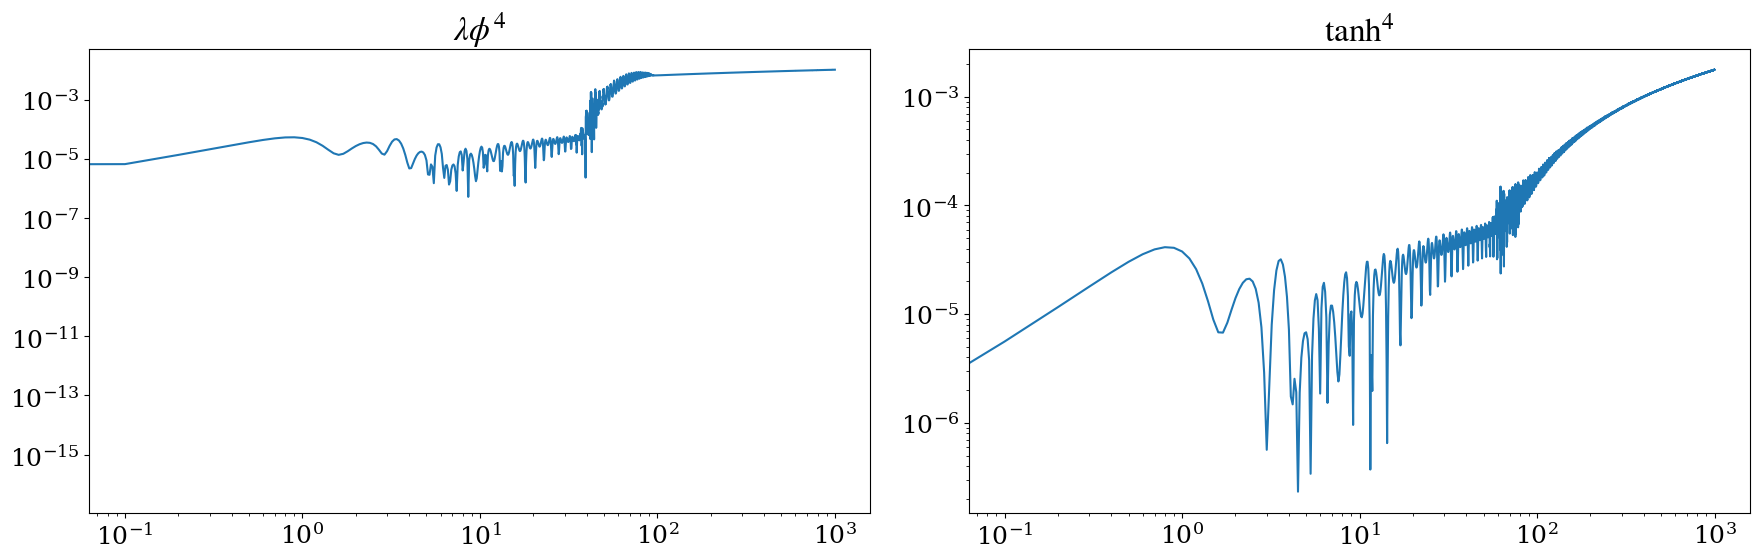

In [7]:
enConsDat_lphi4 = np.loadtxt(dir_lphi4 + "average_energy_conservation.txt")
enConsDat_tanh4 = np.loadtxt(dir_tanh4 + "average_energy_conservation.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(enConsDat_lphi4[:,0], np.abs(enConsDat_lphi4[:,1]))
plt.title(r"$\lambda \phi^4$")
plt.yscale('log')
plt.xscale('log')

plt.subplot(1, 2, 2)
plt.plot(enConsDat_tanh4[:,0], np.abs(enConsDat_tanh4[:,1]))
plt.title(r"$\tanh^4$")
plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

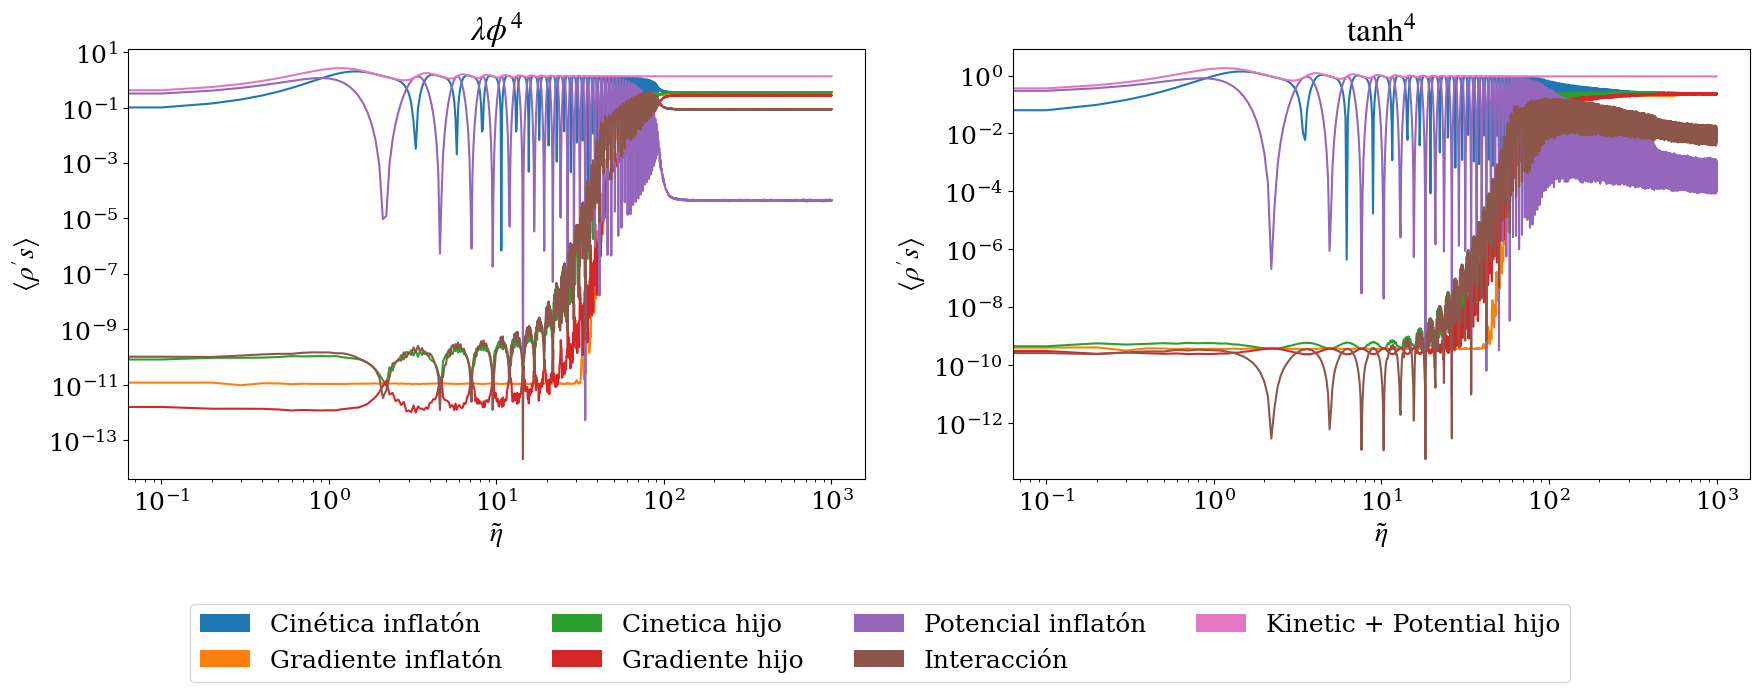

In [8]:
enDat_lphi4 = np.loadtxt(dir_lphi4 + "average_energies.txt")
enDat_tanh4 = np.loadtxt(dir_tanh4 + "average_energies.txt")

nColumns_lphi4 = np.shape(enDat_lphi4)[1]
nColumns_tanh4 = np.shape(enDat_tanh4)[1]

# set explicitly different colors, so we know who is who
label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

fig = plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
for i in range(1,nColumns_lphi4):
    plt.plot(enDat_lphi4[:,0], enDat_lphi4[:,i]*aDat_lphi4[:,1]**4, color = colors[i-1])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.title(r"$\lambda \phi^4$")

plt.subplot(1, 2, 2)
for i in range(1,nColumns_tanh4):
    plt.plot(enDat_tanh4[:,0], enDat_tanh4[:,i]*aDat_tanh4[:,1]**4, color = colors[i-1])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.title(r"$\tanh^4$")

plt.tight_layout()

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)

plt.show()

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [9]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*3)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

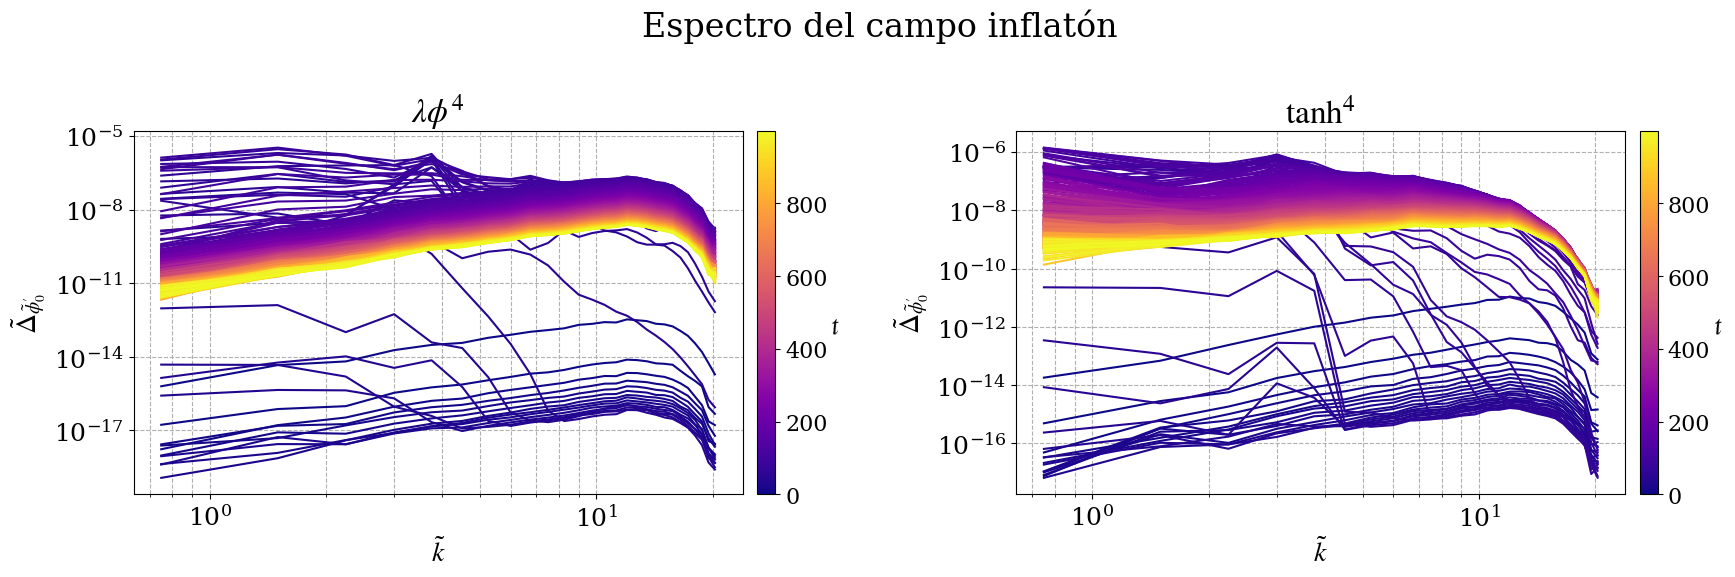

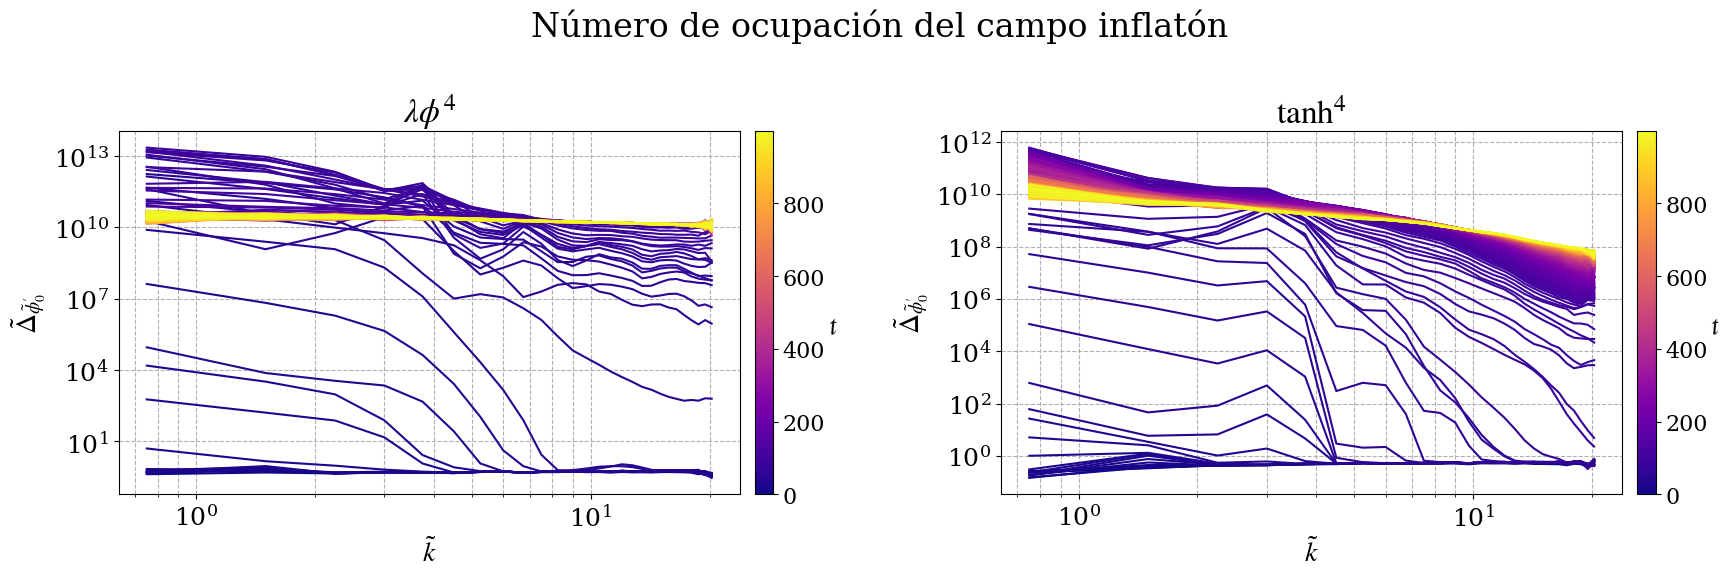

In [10]:
infSp_lphi4, nBins_lphi4, nSpectra_lphi4 = load_spectrum(dir_lphi4 + "spectra_scalar_0.txt")
infSp_tanh4, nBins_tanh4, nSpectra_tanh4 = load_spectrum(dir_tanh4 + "spectra_scalar_0.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_spectrum(infSp_lphi4, 1,  nBins_lphi4, nSpectra_lphi4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plot_spectrum(infSp_tanh4, 1,  nBins_tanh4, nSpectra_tanh4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$\tanh^4$')

plt.suptitle(r'Espectro del campo inflatón')
plt.tight_layout()
plt.show()


plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_spectrum(infSp_lphi4, 3,  nBins_lphi4, nSpectra_lphi4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plot_spectrum(infSp_tanh4, 3,  nBins_tanh4, nSpectra_tanh4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$\tanh^4$')

plt.suptitle(r'Número de ocupación del campo inflatón')
plt.tight_layout()
plt.show()

## Daughter field

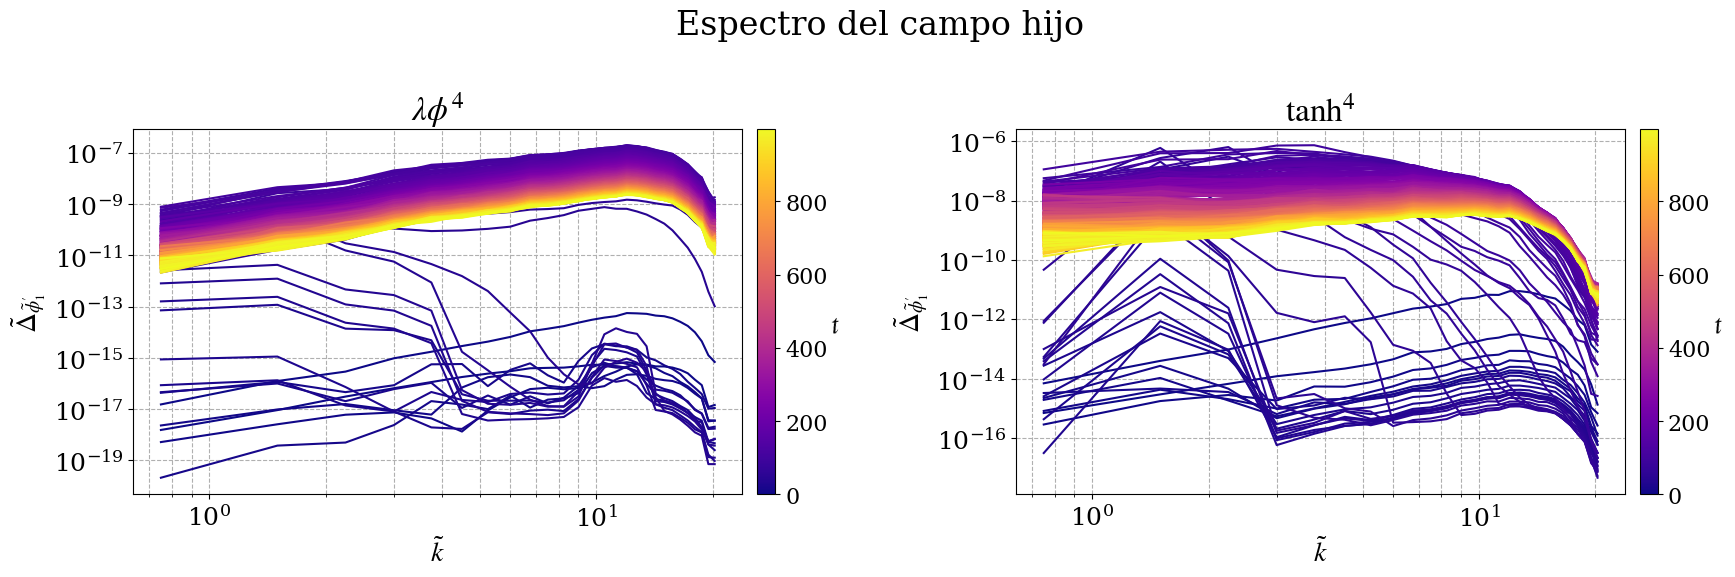

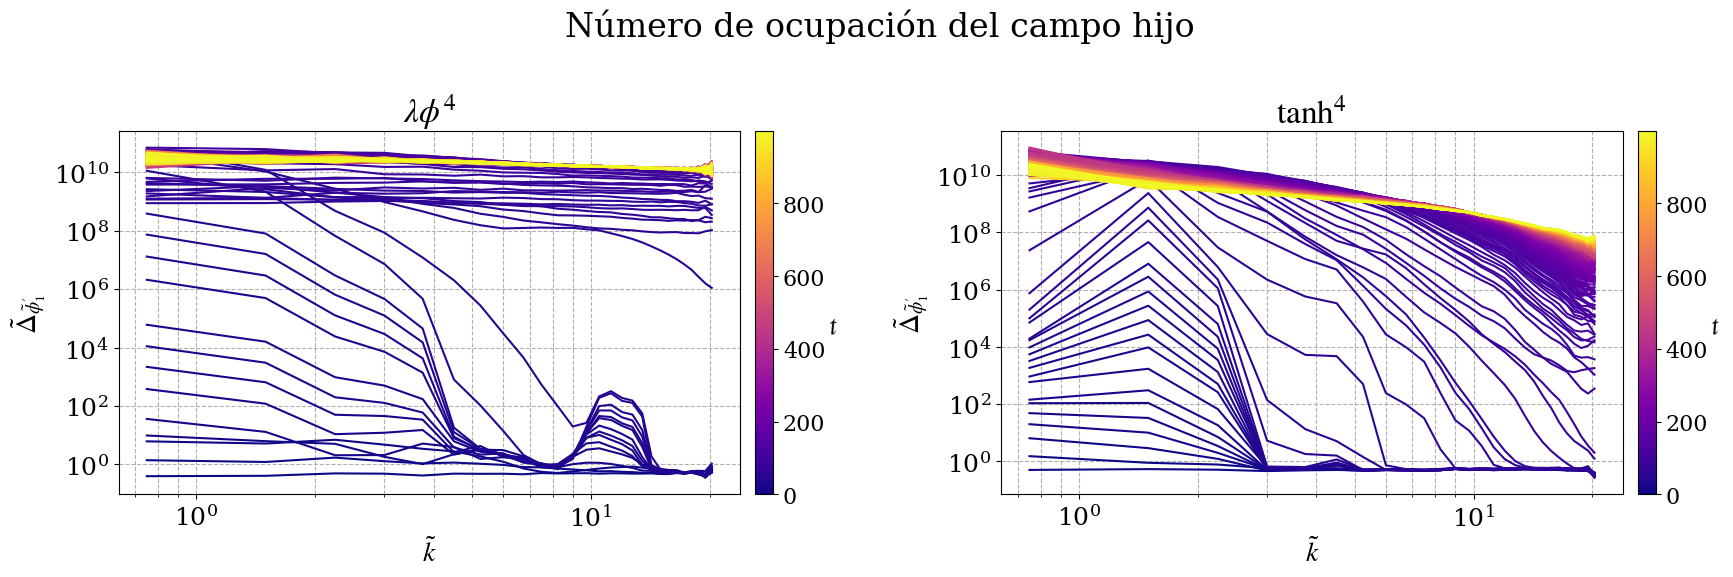

In [11]:
infSp_lphi4, nBins_lphi4, nSpectra_lphi4 = load_spectrum(dir_lphi4 + "spectra_scalar_1.txt")
infSp_tanh4, nBins_tanh4, nSpectra_tanh4 = load_spectrum(dir_tanh4 + "spectra_scalar_1.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_spectrum(infSp_lphi4, 1,  nBins_lphi4, nSpectra_lphi4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plot_spectrum(infSp_tanh4, 1,  nBins_tanh4, nSpectra_tanh4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$\tanh^4$')

plt.suptitle(r'Espectro del campo hijo')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_spectrum(infSp_lphi4, 3,  nBins_lphi4, nSpectra_lphi4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plot_spectrum(infSp_tanh4, 3,  nBins_tanh4, nSpectra_tanh4)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$\tanh^4$')

plt.suptitle(r'Número de ocupación del campo hijo')
plt.tight_layout()
plt.show()

# GWs

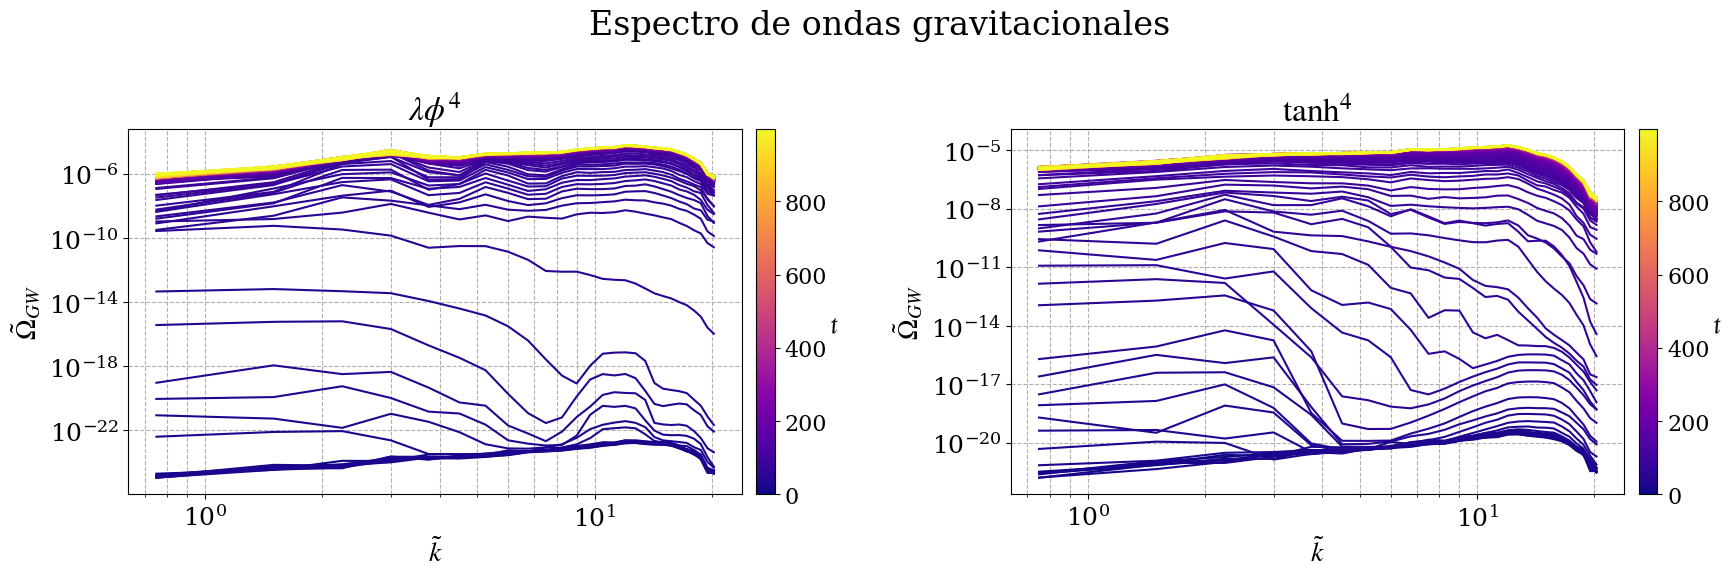

In [12]:
gwSp_lphi4, nBins_lphi4, nSpectra_lphi4 = load_spectrum(dir_lphi4 + "spectra_gws.txt")
gwSp_tanh4, nBins_tanh4, nSpectra_tanh4 = load_spectrum(dir_tanh4 + "spectra_gws.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plot_spectrum(gwSp_lphi4, 1,  nBins_lphi4, nSpectra_lphi4)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plot_spectrum(gwSp_tanh4, 1,  nBins_tanh4, nSpectra_tanh4)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\tanh^4$')

plt.suptitle(r'Espectro de ondas gravitacionales')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

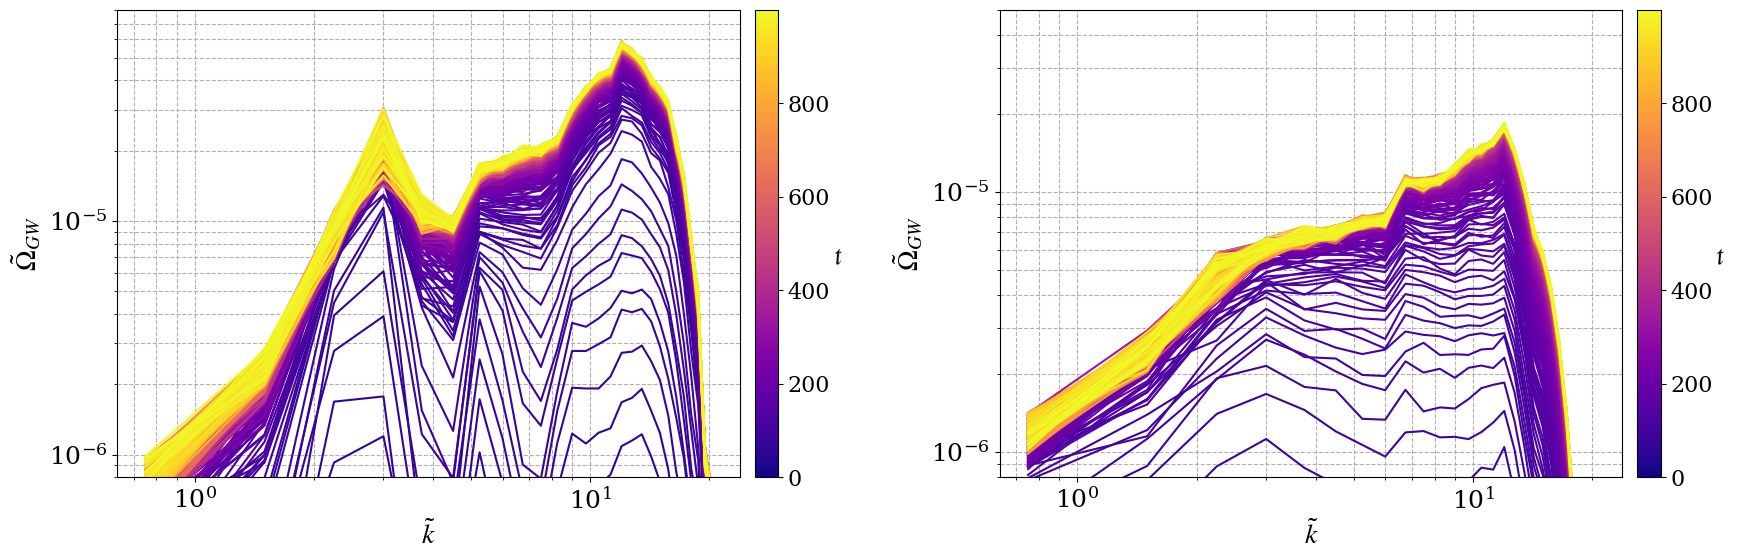

In [13]:
gwSp_lphi4, nBins_lphi4, nSpectra_lphi4 = load_spectrum(dir_lphi4 + "spectra_gws.txt")
gwSp_tanh4, nBins_tanh4, nSpectra_tanh4 = load_spectrum(dir_tanh4 + "spectra_gws.txt")

plt.figure(figsize=(12, 6))

def zoom(gwSp):
    columna_datos = 1 # Es la columna que pasas a plot_spectrum
    # Extraemos solo los valores de esa columna
    datos_y = gwSp[:, columna_datos]

    # 1. Buscamos el máximo valor (ignorando posibles NaNs)
    max_val = np.nanmax(datos_y)

    # 2. Calculamos el orden de magnitud base
    # Si max_val es 2e-14, magnitud_base será 1e-14
    magnitud_base = 10**np.floor(np.log10(max_val))

    # 3. Definimos los límites según tus reglas
    y_max = 8 * magnitud_base
    y_min = y_max / 100
    
    return y_min, y_max

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
y_min, y_max = zoom(gwSp_lphi4)
plot_spectrum(gwSp_lphi4, 1, nBins_lphi4, nSpectra_lphi4)
plt.ylim(y_min, y_max)
plt.ylabel('$\\tilde\Omega_{GW}$');

plt.subplot(1, 2, 2)
y_min, y_max = zoom(gwSp_tanh4)
plot_spectrum(gwSp_tanh4, 1, nBins_tanh4, nSpectra_tanh4)
plt.ylim(y_min, y_max*5/8)
plt.ylabel('$\\tilde\Omega_{GW}$');


plt.tight_layout()
plt.show()

In [14]:
def integrate_spectrum(spectrum, nBins, nSpectra):
    total_energy = []
    for i in range(nSpectra):
        energy = np.trapezoid(spectrum[i*nBins:(i+1)*nBins, 1], spectrum[i*nBins:(i+1)*nBins, 0])
        total_energy.append(energy)
    return total_energy

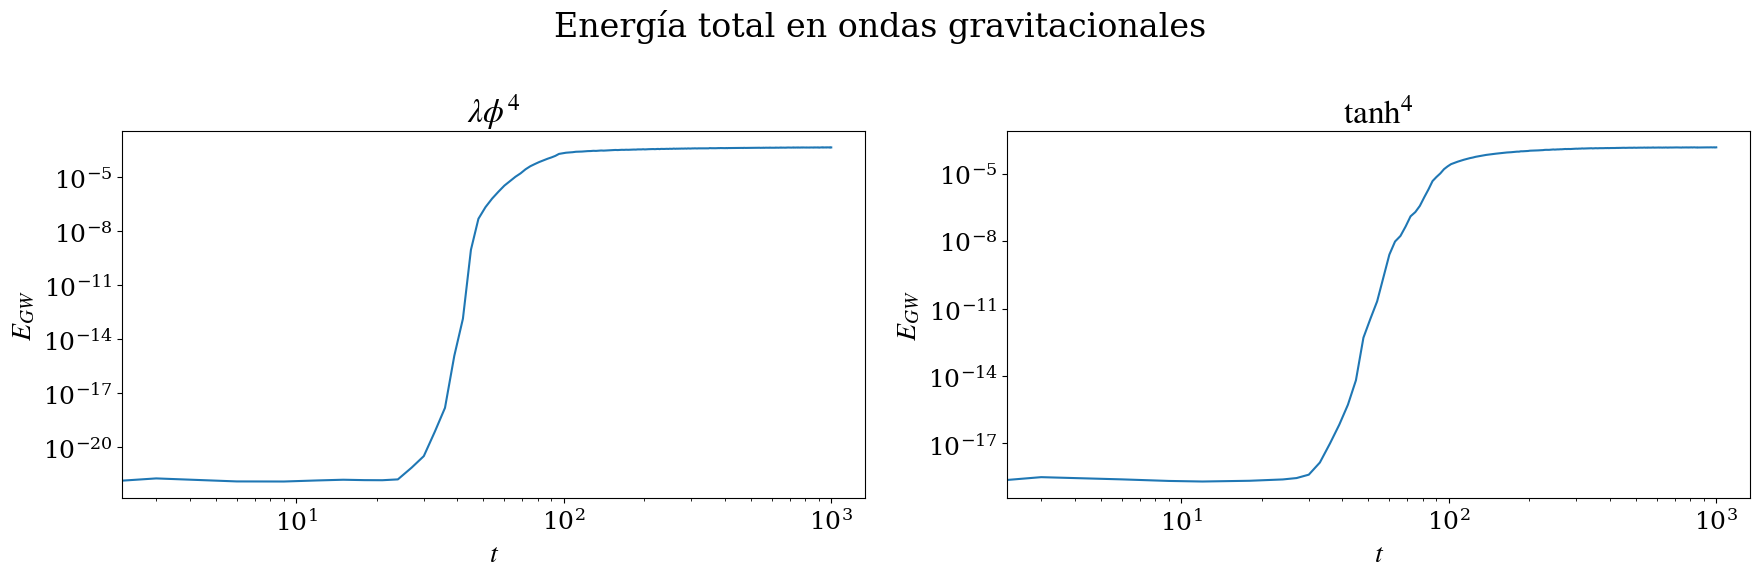

In [15]:
E_lphi4 = integrate_spectrum(gwSp_lphi4, nBins_lphi4, nSpectra_lphi4)
E_tanh4 = integrate_spectrum(gwSp_tanh4, nBins_tanh4, nSpectra_tanh4)

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(np.arange(nSpectra_lphi4)*3, E_lphi4)
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')
plt.title(r'$\lambda \phi^4$')

plt.subplot(1, 2, 2)
plt.plot(np.arange(nSpectra_tanh4)*3, E_tanh4)
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')
plt.title(r'$\tanh^4$')

plt.suptitle(r'Energía total en ondas gravitacionales')
plt.tight_layout()
plt.show()

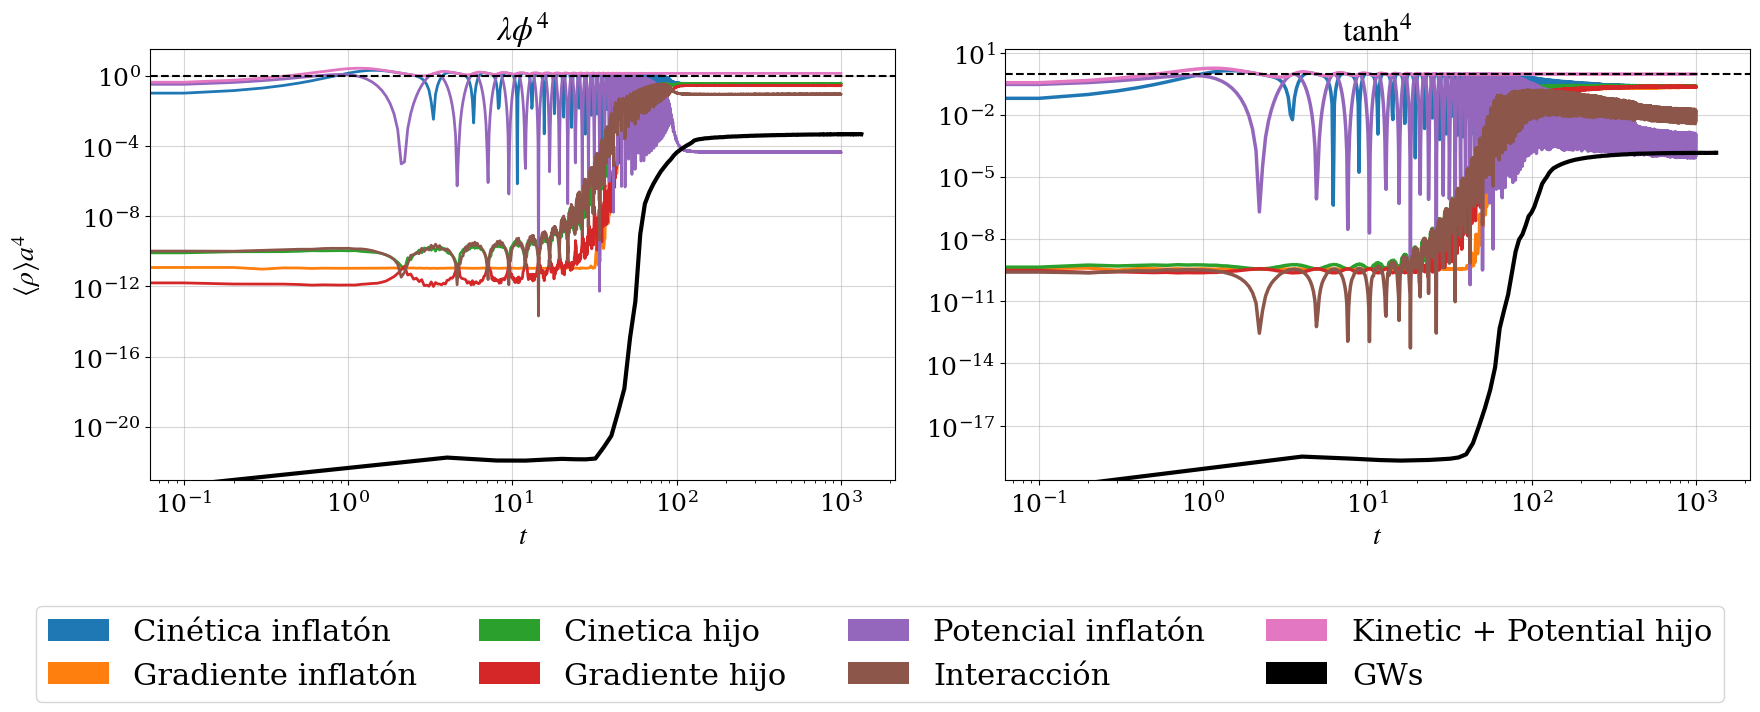

In [16]:
fig = plt.figure(figsize=(18, 6))

label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo", "GWs"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "black"]

plt.subplot(1, 2, 1)
for i in range(1,nColumns_lphi4):
    plt.plot(enDat_lphi4[:,0], enDat_lphi4[:,i]*aDat_lphi4[:,1]**4, color = colors[i-1], lw = 2)
plt.plot(np.arange(nSpectra_lphi4)*4, E_lphi4, color = 'black', lw = 3)
plt.axhline(y = 1, ls = "--", color = "black")
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel(r'$\langle \rho \rangle a^4$', labelpad = 20)
plt.title(r'$\lambda \phi^4$')
plt.grid(alpha = 0.5)

plt.subplot(1, 2, 2)
for i in range(1,nColumns_tanh4):
    plt.plot(enDat_tanh4[:,0], enDat_tanh4[:,i]*aDat_tanh4[:,1]**4, color = colors[i-1], lw = 2.5)
plt.plot(np.arange(nSpectra_tanh4)*4, E_tanh4, color = 'black', lw = 3)
plt.axhline(y = 1, ls = "--", color = "black")
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$t$')
plt.title(r'$\tanh^4$')
plt.grid(alpha = 0.5)

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=22)

plt.tight_layout()
#plt.show()
plt.savefig("CosmoLattice_energies_lphi4tanh4.pdf", format = "pdf", bbox_inches="tight")

# Calculo de los espectros hoy

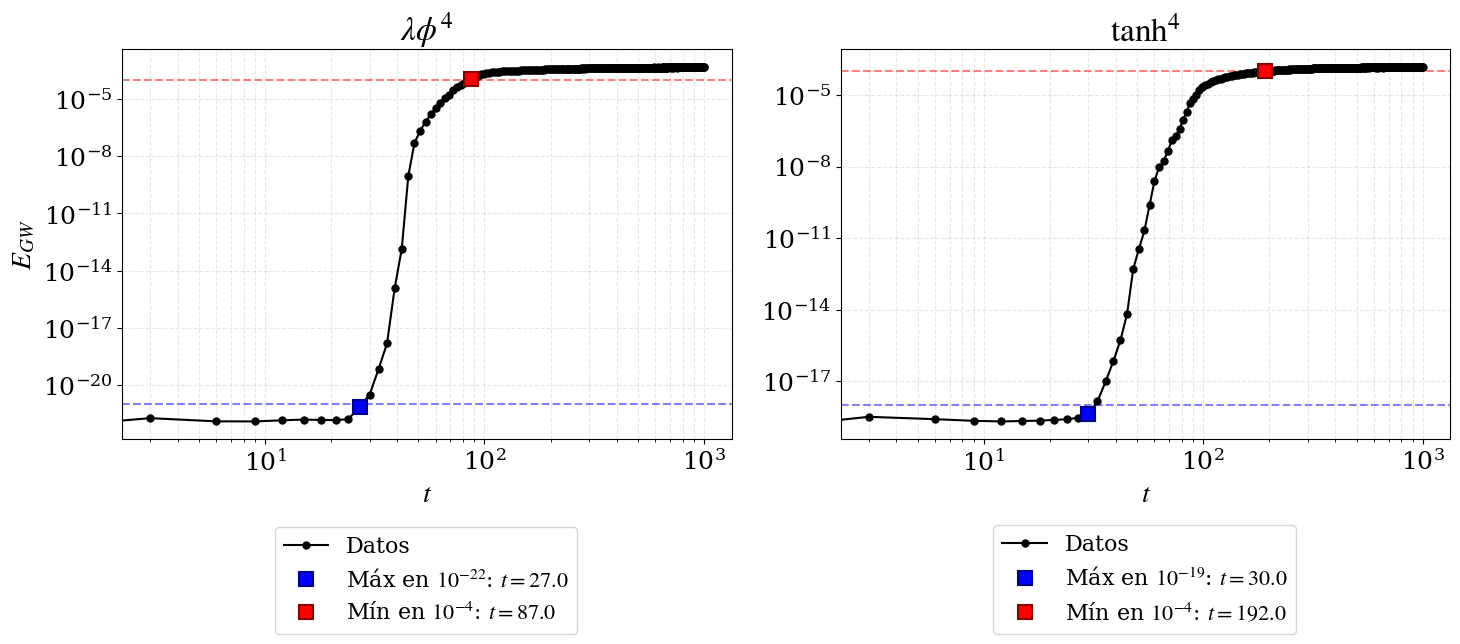

In [17]:
# =====================================================================
# 1. FUNCIONES DE LECTURA E INTEGRACIÓN
# =====================================================================
def load_gws(filename, comment='#'):
    file = open(filename)
    nBins = 0
    line = file.readline()
    while line != "\n":
        if line and line[0] != comment:
            nBins += 1
        line = file.readline()
    file.close()

    fileSp = np.loadtxt(filename, comments=comment)
    nSpectra = len(fileSp) // nBins
    return fileSp, int(nBins), int(nSpectra)

def integrate_gw_spectrum(gw_data, nBins, nSpectra):
    """
    Integra el espectro de GWs para cada tiempo de salida
    usando la regla del trapecio.
    """
    total_energy = []
    for i in range(nSpectra):
        k = gw_data[i*nBins:(i+1)*nBins, 0]
        delta_h = gw_data[i*nBins:(i+1)*nBins, 1]
        energy = np.trapezoid(delta_h, k)
        total_energy.append(energy)
    return np.array(total_energy)

# =====================================================================
# 2. FUNCIONES DE ANÁLISIS DE ESCALA
# =====================================================================
def analyze_scale_transitions(t_data, E_data):
    """Identifica transiciones entre órdenes de magnitud."""
    E_data = np.asarray(E_data, dtype=float)
    t_data = np.asarray(t_data, dtype=float)
    
    valid_mask = (E_data > 0) & np.isfinite(E_data) & np.isfinite(t_data)
    valid_indices = np.where(valid_mask)[0]
    
    if len(valid_indices) == 0:
        return None
    
    E_valid = E_data[valid_indices]
    t_valid = t_data[valid_indices]
    
    magnitudes = np.floor(np.log10(E_valid))
    min_magnitude = int(magnitudes.min())
    max_magnitude = int(magnitudes.max())
    
    idx_min_mag_group = np.where(magnitudes == min_magnitude)[0]
    idx_max_mag_group = np.where(magnitudes == max_magnitude)[0]
    
    local_max_in_min = np.argmax(E_valid[idx_min_mag_group])
    idx_max_in_min = valid_indices[idx_min_mag_group[local_max_in_min]]
    
    local_min_in_max = np.argmin(E_valid[idx_max_mag_group])
    idx_min_in_max = valid_indices[idx_max_mag_group[local_min_in_max]]
    
    return {
        'min_magnitude': min_magnitude,
        'max_magnitude': max_magnitude,
        'idx_max_in_min': idx_max_in_min,
        't_max_in_min': t_data[idx_max_in_min],
        'E_max_in_min': E_data[idx_max_in_min],
        'idx_min_in_max': idx_min_in_max,
        't_min_in_max': t_data[idx_min_in_max],
        'E_min_in_max': E_data[idx_min_in_max],
        'n_valid': len(valid_indices),
        'n_total': len(E_data),
    }

def print_scale_analysis(analysis):
    """Imprime el reporte en la consola de forma estructurada."""
    print(f"Valores procesados: {analysis['n_valid']}/{analysis['n_total']}")
    print(f"Rango de órdenes de magnitud: 10^{analysis['min_magnitude']} a 10^{analysis['max_magnitude']}")
    
    print(f"1. MÁX CON MENOR ORDEN (10^{analysis['min_magnitude']}):")
    print(f"   t = {analysis['t_max_in_min']:.2f} | E = {analysis['E_max_in_min']:.6e}")
    
    print(f"2. MÍN CON MAYOR ORDEN (10^{analysis['max_magnitude']}):")
    print(f"   t = {analysis['t_min_in_max']:.2f} | E = {analysis['E_min_in_max']:.6e}")
    print(f"Ratio de energías: {analysis['E_min_in_max'] / analysis['E_max_in_min']:.2e}\n")

def plot_scale_transitions(t_data, E_data, analysis, ax):
    """Genera el gráfico inyectándolo en el eje (ax) provisto."""
    ax.plot(t_data, E_data, 'o-', markersize=5, label='Datos', color='black', linewidth=1.5, zorder=3)

    idx1, t1, E1, mag_min = analysis['idx_max_in_min'], analysis['t_max_in_min'], analysis['E_max_in_min'], analysis['min_magnitude']
    idx2, t2, E2, mag_max = analysis['idx_min_in_max'], analysis['t_min_in_max'], analysis['E_min_in_max'], analysis['max_magnitude']

    # Marcadores
    ax.plot(t1, E1, 's', markersize=10, 
             label=fr"Máx en $10^{{{mag_min}}}$: $t={t1:.1f}$", 
             color='blue', zorder=4, markeredgecolor='darkblue', markeredgewidth=1.5)

    ax.plot(t2, E2, 's', markersize=10, 
             label=fr"Mín en $10^{{{mag_max}}}$: $t={t2:.1f}$", 
             color='red', zorder=4, markeredgecolor='darkred', markeredgewidth=1.5)

    # Líneas horizontales
    ax.axhline(10*10**mag_min, color='blue', linestyle='--', lw=1.5, alpha=0.5)
    ax.axhline(10**mag_max, color='red', linestyle='--', lw=1.5, alpha=0.5)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.legend(fontsize=16, loc=(0.25,-0.5))
    ax.grid(True, which="both", ls="--", alpha=0.3)

# =====================================================================
# 3. FUNCIÓN PRINCIPAL DE PLOTEO (GRILLA 3x4)
# =====================================================================
def plot_combined_gw_energies(dirs, q_val_labels, verbose=False):
    """
    Gráfica la evolución temporal de la energía total de las GWs 
    aplicando el análisis de transiciones de escala en una grilla 3x4.
    """
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(15, 6))
    
    for i in range(2):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((1, 2), (row, col))
        path = os.path.join(dirs[i], filename)
        
        if os.path.exists(path):
            sp, nBins, nSpec = load_gws(path)
            e_gw = integrate_gw_spectrum(sp, nBins, nSpec)
            
            # Vector de tiempo (ajusta el * 3 si el paso temporal de estas sim es distinto)
            t_gw = np.arange(nSpec) * 3 
            
            # Análisis y graficado
            analysis = analyze_scale_transitions(t_gw, e_gw)
            
            if analysis is not None:
                plot_scale_transitions(t_gw, e_gw, analysis, ax=ax)
                if verbose:
                    print(f"--- ANÁLISIS PARA: {q_val_labels[i]} ---")
                    print_scale_analysis(analysis)
            else:
                # Fallback estándar
                ax.plot(t_gw, e_gw, color='tab:red', lw=2)
                ax.set_yscale('log')
                ax.set_xscale('log')
                ax.grid(True, which="both", ls="--", alpha=0.3)
        else:
            # Si no existe el archivo, dejar el panel vacío con un aviso
            ax.text(0.5, 0.5, 'Datos no encontrados', ha='center', va='center', transform=ax.transAxes)
        
        # Estilos de los subplots
        ax.set_title(fr"{q_val_labels[i]}")
        ax.set_xlabel(r"$t$")
        if col == 0: 
            ax.set_ylabel(r"$E_{GW}$")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# =====================================================================
# 4. EJECUCIÓN
# =====================================================================
plot_combined_gw_energies([dir_lphi4, dir_tanh4], [r"$\lambda \phi^4$", r"$\tanh^4$"])
plt.tight_layout()
plt.savefig("CosmoLattice_GW_Scale_Analysis_lphi4tanh4.pdf", format="pdf", bbox_inches="tight")

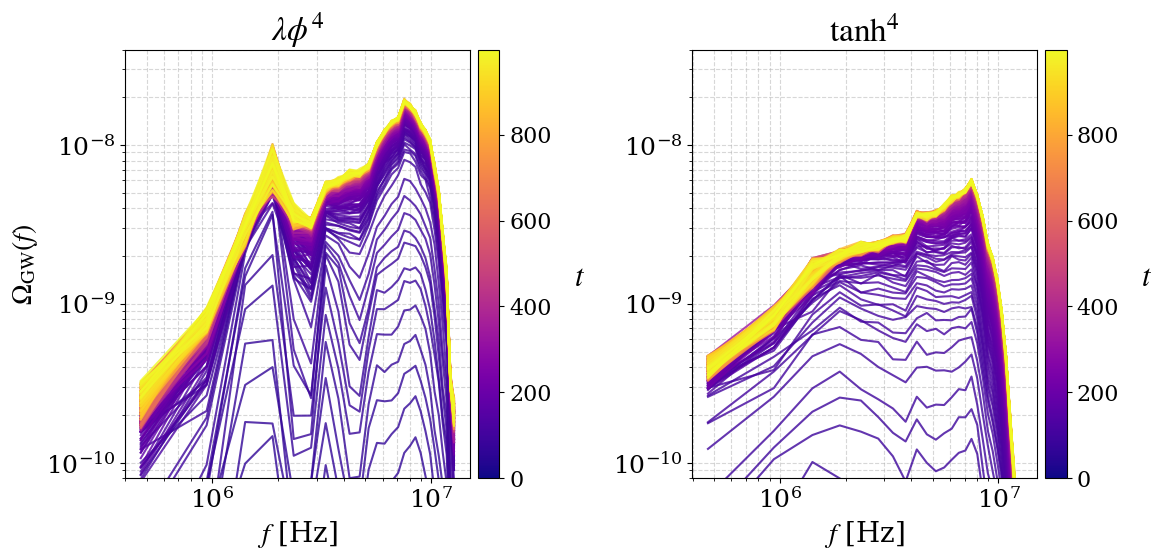

In [18]:
# =====================================================================
# 1. FUNCIÓN DE LECTURA DE DATOS
# =====================================================================
def load_gws(filename, comment='#'):
    """Carga los espectros de GWs manejando los saltos de línea."""
    with open(filename, 'r') as file:
        nBins = 0
        line = file.readline()
        while line and line != "\n":
            if line[0] != comment:
                nBins += 1
            line = file.readline()
    
    fileSp = np.loadtxt(filename, comments=comment)
    nSpectra = len(fileSp) // nBins
    return fileSp, int(nBins), int(nSpectra)

# =====================================================================
# 2. FUNCIÓN DE GRAFICADO INDIVIDUAL (Soporta ftoday y filtrado)
# =====================================================================
def plot_gw_into_ax(ax, gw_data, nBins, nSpectra, 
                    Treh=None, T0=None, omegaStar=None, spectrum_index=None, 
                    ylabel=r'$\tilde{\Delta}_h$', colormap='plasma'):
    """
    Dibuja el espectro de GWs en un eje específico.
    Si se proveen Treh, T0 y omegaStar, escala los datos a variables actuales (ftoday).
    """
    colors = plt.get_cmap(colormap)
    
    # Lógica de filtrado de índices
    if spectrum_index is not None:
        if isinstance(spectrum_index, int) and spectrum_index < 0:
            indices_to_plot = [nSpectra + spectrum_index]
        elif isinstance(spectrum_index, list):
            indices_to_plot = [(nSpectra + idx if idx < 0 else idx) for idx in spectrum_index]
        else:
            indices_to_plot = [spectrum_index]
    else:
        indices_to_plot = range(nSpectra)

    # Asumiendo dt = 3 entre espectros para la barra de colores
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*3)
    
    for i in indices_to_plot:
        if i >= nSpectra or i < 0:
            continue
            
        k_vals = gw_data[i*nBins:(i+1)*nBins, 0]
        amp_vals = gw_data[i*nBins:(i+1)*nBins, 1]
        
        # Escalar a "hoy" si se pasaron los parámetros cosmológicos
        if all(v is not None for v in [Treh, T0, omegaStar]):
            k_vals = k_vals * (T0 / Treh) * (omegaStar / (2 * np.pi))
            amp_vals = amp_vals * (1 / 3000)
            xlabel = r'$f$ [Hz]' # Cambia el rótulo del eje X
        else:
            xlabel = r'$\tilde{k}$'
            
        ax.plot(k_vals, amp_vals, color=colors(i / nSpectra), alpha=0.8)
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', ls='--', alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Solo mostrar Colorbar si se está graficando más de un espectro
    if spectrum_index is None or (isinstance(spectrum_index, list) and len(spectrum_index) > 1):
        sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label(r'$t$', fontsize=22, rotation=0, labelpad=20)
        cbar.ax.tick_params(labelsize=16)

# =====================================================================
# 3. FUNCIÓN PRINCIPAL DE LA GRILLA
# =====================================================================
def plot_combined_gws_case(dirs, q_val_labels, 
                           Treh=None, T0=None, omegaStar=None, 
                           spectrum_index=None):
    """
    Gráfica en una grilla 3x4 los espectros de GWs.
    Permite pasar parámetros para escalar a ftoday y filtrar índices.
    """
    filename = "spectra_gws.txt"
    fig = plt.figure(figsize=(12, 6))
    ylabel = r'$\Omega_{\text{GW}} (f)$'
    
    for i in range(2):
        row, col = divmod(i, 2)
        ax = plt.subplot2grid((1, 2), (row, col))
        path = os.path.join(dirs[i], filename)
        
        if os.path.exists(path):
            sp, nBins, nSpec = load_gws(path)
            
            # Si se pasó una lista de 12 índices (uno para cada panel), extraer el que corresponde
            current_idx = spectrum_index[i] if isinstance(spectrum_index, list) and len(spectrum_index) == 12 else spectrum_index
            
            y_min, y_max = zoom(sp)
            plot_gw_into_ax(ax, sp, nBins, nSpec, 
                            Treh=Treh, T0=T0, omegaStar=omegaStar, 
                            spectrum_index=current_idx,
                            ylabel=ylabel, colormap='plasma')
            plt.ylim(y_min/1e4, y_max/2e3)
        else:
            ax.text(0.5, 0.5, 'Datos no encontrados', ha='center', va='center', transform=ax.transAxes, fontsize=14)
            ax.set_xscale('log')
            ax.set_yscale('log')
            
        ax.set_title(fr"{q_val_labels[i]}")
        
        # Limpieza visual: Ocultar el 'ylabel' en las columnas 2, 3 y 4
        if col != 0:
            ax.set_ylabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plot_combined_gws_case([dir_lphi4, dir_tanh4], [r"$\lambda \phi^4$", r"$\tanh^4$"], Treh=1e10, T0=2.7, omegaStar=1.46e16)
plt.tight_layout()
plt.savefig("CosmoLattice_GW_Spectra_today_lphi4tanh4.pdf", format="pdf")

In [19]:
"""Guardar espectro hc del tiempo mayor"""
H0 = 2.3e-18 #Hz

infDat_tanh4 = np.loadtxt(dir_tanh4 + "average_scalar_0.txt")
infDat_lphi4 = np.loadtxt(dir_lphi4 + "average_scalar_0.txt")

"""Variables"""
Omega_RAD = 8.6e-5
greh = 106.5
g0 = 3.36
gs0 = 3.91
gsreh = 106.5
kB = 8.617333e-14                        #GeV/K
h = 4.134e-24                            #GeV*s
Treh = 1e10                              #GeV
T0 = 2.726 * kB                          #GeV
omega = 1/3                              #RAD

l = 9e-14
Lambda4 = 1.7966e65 
phi0 = 7.42675e18
fStar = phi0
omegaStar = np.sqrt(l)*fStar
nindex = -1
ai, af = aDat_lphi4[0,1], aDat_lphi4[nindex,1]
Vi = enDat_lphi4[0,5]*(fStar**2*omegaStar**2) #Potencial inicial del inflatón, que es el que domina la energía al principio

"""Escaleos"""
f0 = omegaStar/(2 * np.pi * h) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
Omega0 = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)

# Índice del último espectro (tiempo mayor)
spectrum_index = nSpectra_lphi4 - 1

# Extraer los datos para ese espectro
k_index = np.arange(spectrum_index * nBins_lphi4, (spectrum_index + 1) * nBins_lphi4)
f_today = gwSp_lphi4[k_index, 0] * f0
h_c = np.sqrt(gwSp_lphi4[k_index, 1] * Omega0) * np.sqrt(3) / np.pi * H0 / f_today

# Crear matriz con x e y
data_to_save = np.column_stack((f_today, h_c))

# Guardar en archivo
output_file = "strain_spectrum_lphi4.txt"
np.savetxt(output_file, data_to_save, header='f_0 [Hz]            h_c(f_0, t_0)', fmt='%.6e')


Lambda4 = 1.7966e65 
phi0 = 7.42675e18
fStar = phi0
omegaStar = np.sqrt(l)*fStar
nindex = -1
ai, af = aDat_tanh4[0,1], aDat_tanh4[nindex,1]
Vi = enDat_tanh4[0,5]*(fStar**2*omegaStar**2) #Potencial inicial del inflatón, que es el que domina la energía al principio

"""Escaleos"""
f0 = omegaStar/(2 * np.pi * h) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
Omega0 = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)

spectrum_index = nSpectra_tanh4 - 1

# Extraer los datos para ese espectro
k_index = np.arange(spectrum_index * nBins_tanh4, (spectrum_index + 1) * nBins_tanh4)
f_today = gwSp_tanh4[k_index, 0] * f0
h_c = np.sqrt(gwSp_tanh4[k_index, 1] * Omega0) * np.sqrt(3) / np.pi * H0 / f_today

# Crear matriz con x e y
data_to_save = np.column_stack((f_today, h_c))

# Guardar en archivo
output_file = "strain_spectrum_tanh4.txt"
np.savetxt(output_file, data_to_save, header='f_0 [Hz]            h_c(f_0, t_0)', fmt='%.6e')